# 05b — Neural Network Comparisons

Run notebook 03 first. This branch uses its train-fitted ANN representation directly, including skew correction and FFT PCA. It follows the reference's linear → 128/64 SGD → 128/64 Adam → batch normalization/dropout progression, with a 64/32 architecture control. All five models use Keras for consistent training and checkpoint behavior; the control is not an exact reproduction of the old scikit-learn baseline.

Entire test turbines are held out; validation uses later observations from development turbines. All models receive the same training-derived balanced sample weights, up to 30 epochs, and validation-loss early stopping with patience 5. The regularized model uses 50% dropout and batch normalization after each hidden layer. Hidden Dense layers use L2=0.0001.

Select the model by validation PR-AUC, then its threshold by validation F2 to emphasize failure recall while accounting for precision. Test results never select a model or threshold. These held-out turbines may have appeared in older experiments, so this is a new evaluation protocol, not a previously unseen external test dataset.

In [1]:
from pathlib import Path
import sys
import json
import shutil
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
root = Path.cwd()
if not (root / 'src').exists():
    root = root.parent
sys.path.insert(0, str(root))
from src.modeling.neural_networks import load_data, train_comparison, evaluate_selected, CONFIGS
output = root / 'models/neural_network_comparison'
output.mkdir(parents=True, exist_ok=True)
data = load_data(root)
shutil.copy2(root / 'data/processed/03_ann_preprocessor.joblib', output / 'preprocessor.joblib')
shutil.copy2(root / 'data/processed/03_ann_manifest.json', output / 'data_manifest.json')
display(pd.DataFrame(CONFIGS))
display(pd.DataFrame([{'split': s, 'rows': len(data[f'y_{s}']), 'features': data[f'X_{s}'].shape[1]} for s in ['train', 'validation', 'test']]))

Matplotlib is building the font cache; this may take a moment.


,name,hidden,optimizer,lr,batch,dropout
0,linear_sgd,(),sgd,0.0100,32,0.0
1,128_64_sgd,"(128, 64)",sgd,0.0100,32,0.0
2,128_64_adam,"(128, 64)",adam,0.0001,32,0.0
3,128_64_bn_dropout,"(128, 64)",adam,0.0001,128,0.5
4,64_32_adam_control,"(64, 32)",adam,0.0010,256,0.0


,split,rows,features
0,train,84336,25
1,validation,21072,25
2,test,26352,25


## Train and compare on validation data

The five training-log blocks below follow this order. Each restart at `Epoch 1/30` begins the next model:

| Log block | Model | Optimizer | Learning rate | Batch size | Recorded epochs |
| --- | --- | --- | --- | --- | --- |
| 1 | Linear | SGD with momentum 0.9 | 0.01 | 32 | 11 |
| 2 | 128/64 | SGD with momentum 0.9 | 0.01 | 32 | 10 |
| 3 | 128/64 | Adam | 0.0001 | 32 | 11 |
| 4 | 128/64 + batch normalization and 50% dropout | Adam | 0.0001 | 128 | 16 |
| 5 | 64/32 control | Adam | 0.001 | 256 | 11 |

An epoch is one pass through the training data. Training allows up to 30 epochs, stops after five epochs without validation-loss improvement, and restores the best weights. The epoch counts describe training duration, not the epoch of the restored checkpoint.

The 128/64 Adam configuration achieved validation PR-AUC 0.5646 versus 0.4975 for SGD. Learning rates also differ, so these results compare configurations and do not isolate optimizer effects. The regularized configuration also changes batch size; its differences cannot be attributed solely to dropout or batch normalization.

The recorded `shuffle=True` warnings are informational: `dataset()` explicitly shuffles the training dataset before batching. The logs are retained as execution evidence. The comparison table following the logs and the learning curves summarize the results.


In [2]:
comparison, histories, selection = train_comparison(data, output, epochs=30)
display(comparison)
print('Frozen selection:', selection)

Epoch 1/30


/Users/namees.local/Desktop/Wind Turbine Failure Detection/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2636/2636 - 1s - 315us/step - loss: 0.2007 - val_loss: 0.4099


Epoch 2/30


2636/2636 - 1s - 231us/step - loss: 0.1788 - val_loss: 0.4332


...

330/330 - 0s - 494us/step - loss: 0.0384 - val_loss: 0.3591


Epoch 11/30


330/330 - 0s - 492us/step - loss: 0.0351 - val_loss: 0.3010


,model,split,epochs,recall,precision,f1,f2,pr_auc,roc_auc
0,linear_sgd,train,11,0.952051,0.223403,0.361887,0.576191,0.360667,0.973789
1,linear_sgd,validation,11,0.817508,0.313209,0.452901,0.618378,0.400603,0.914702
2,128_64_sgd,train,10,1.000000,0.575590,0.730634,0.871483,0.907447,0.998035
3,128_64_sgd,validation,10,0.797980,0.436625,0.564420,0.684654,0.497538,0.948081
4,128_64_adam,train,11,1.000000,0.541234,0.702339,0.855047,0.908056,0.998245
5,128_64_adam,validation,11,0.817508,0.447970,0.578784,0.701734,0.564624,0.952956
6,128_64_bn_dropout,train,16,1.000000,0.303182,0.465295,0.685087,0.796278,0.994719
7,128_64_bn_dropout,validation,16,0.919192,0.322010,0.476939,0.670498,0.558036,0.945823
8,64_32_adam_control,train,11,0.998934,0.611347,0.758495,0.886525,0.918675,0.998379
9,64_32_adam_control,validation,11,0.707071,0.461538,0.558511,0.639075,0.547778,0.948368


Frozen selection: {'model': '128_64_adam', 'threshold': 0.29000000000000004, 'criterion': 'validation PR-AUC; threshold by validation F2'}


## Learning curves
Training loss includes class weighting and training-time dropout; validation loss is unweighted and evaluated in inference mode. Their absolute levels are not directly comparable.

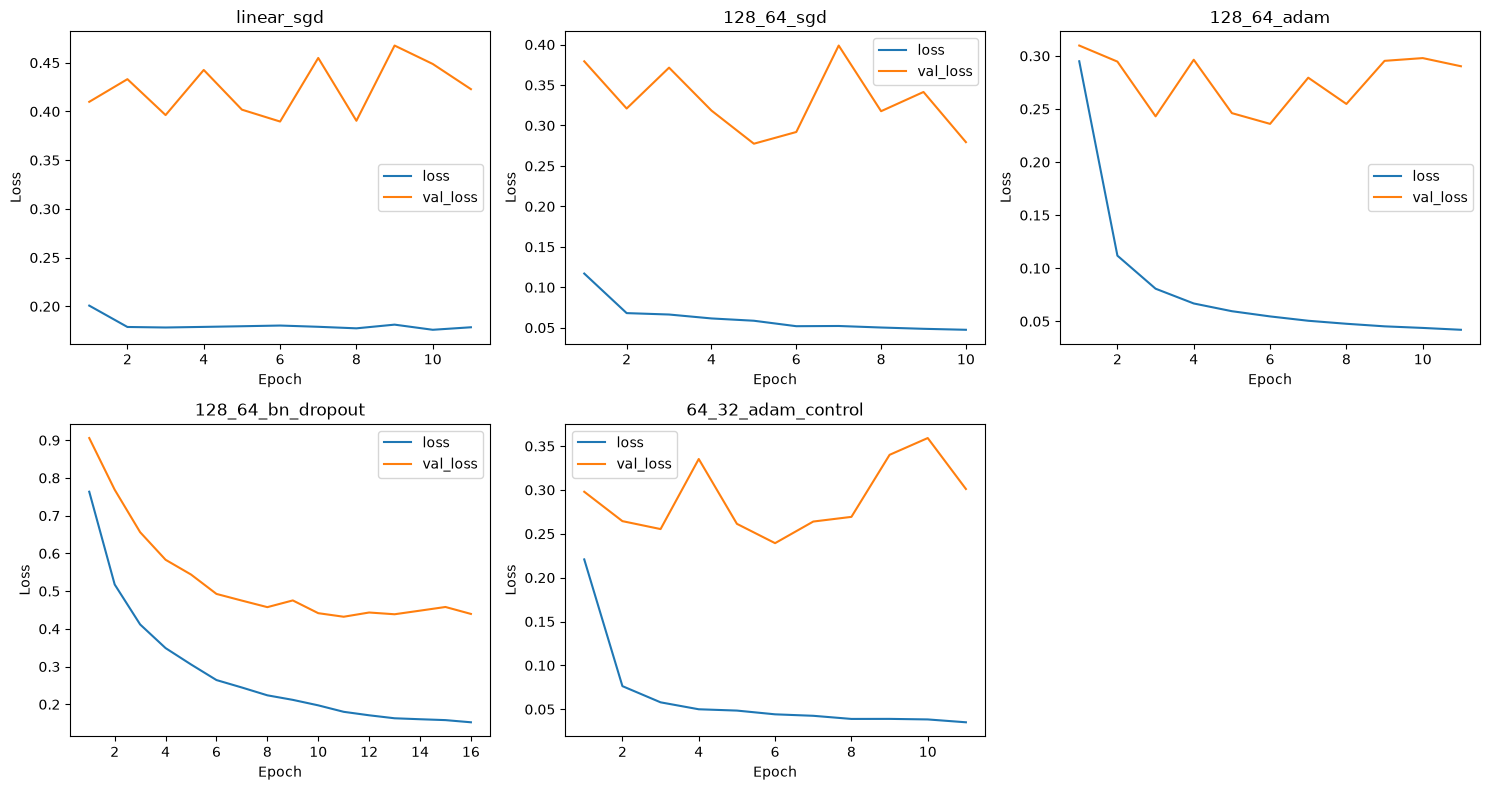

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, history) in zip(axes.flat, histories.items()):
    for key in ['loss', 'val_loss']:
        ax.plot(range(1, len(history[key])+1), history[key], label=key)
    ax.set(title=name, xlabel='Epoch', ylabel='Loss')
    ax.legend()
axes.flat[-1].axis('off')
fig.tight_layout()
fig.savefig(output / 'learning_curves.png', dpi=150)
plt.show()

## Downstream handoff

Stage 06 compares the validation-selected neural checkpoint with tuned tree pipelines using validation PR-AUC and F2. Stage 07 evaluates only the overall selected checkpoint. Earlier exploratory test results have already been viewed; they must not influence selection and are not independent confirmation.

## Key Findings Recap

- Five Keras architectures share the verified stage-03 representation.
- The recorded comparison selected 128/64 Adam by validation PR-AUC (0.5646).
- The 64/32 control achieved validation PR-AUC 0.5478.
- Batch normalization and dropout improved recall at 0.5 but did not lead PR-AUC.
- The saved validation-selected threshold was 0.29.
- Final cross-family selection and test evaluation now belong to stages 06 and 07.